In [2]:
import pandas as pd

data = pd.read_csv('C:/Users/Dell/Downloads/python practice/Data-Science-Practice/Clusterring and Classification/data.csv')
# show first file lines.
data.head()
# show summary
print(data.describe())
print(data.columns)

             job_id  years_experience  skills_python    skills_sql  \
count  10345.000000      10345.000000   10345.000000  10345.000000   
mean    5173.000000          6.950507       0.493088      0.503045   
std     2986.488601          4.320054       0.499976      0.500015   
min        1.000000          0.000000       0.000000      0.000000   
25%     2587.000000          3.000000       0.000000      0.000000   
50%     5173.000000          7.000000       0.000000      1.000000   
75%     7759.000000         11.000000       1.000000      1.000000   
max    10345.000000         14.000000       1.000000      1.000000   

          skills_ml  skills_deep_learning  skills_cloud        salary  \
count  10345.000000          10345.000000  10345.000000   10345.00000   
mean       0.507878              0.498018      0.511455  113438.22726   
std        0.499962              0.500020      0.499893   31389.20106   
min        0.000000              0.000000      0.000000   45083.00000   
25% 

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                10345 non-null  int64
 1   job_title             10345 non-null  str  
 2   company_size          10345 non-null  str  
 3   company_industry      10345 non-null  str  
 4   country               10345 non-null  str  
 5   remote_type           10345 non-null  str  
 6   experience_level      10345 non-null  str  
 7   years_experience      10345 non-null  int64
 8   education_level       10345 non-null  str  
 9   skills_python         10345 non-null  int64
 10  skills_sql            10345 non-null  int64
 11  skills_ml             10345 non-null  int64
 12  skills_deep_learning  10345 non-null  int64
 13  skills_cloud          10345 non-null  int64
 14  salary                10345 non-null  int64
 15  job_posting_month     10345 non-null  int64
 16  job_posting_yea

In [4]:
data.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


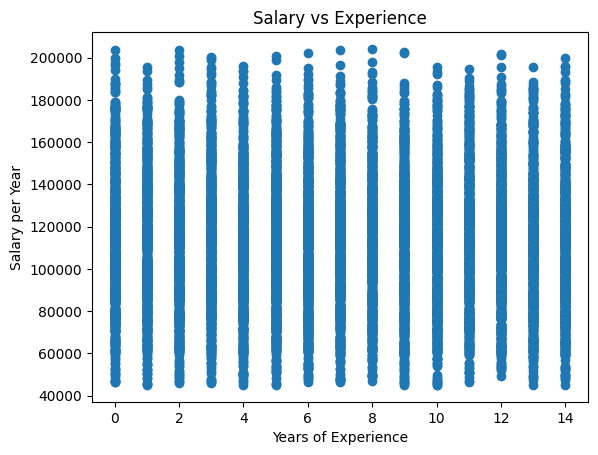

In [8]:
import matplotlib.pyplot as plt

plt.scatter(data['years_experience'],data['salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary per Year')
plt.title('Salary vs Experience')
plt.show()

In [11]:
"""
This is the template file for the clustering and fitting assignment.
You will be expected to complete all the sections and
make this a fully working, documented file.
You should NOT change any function, file or variable names,
 if they are given to you here.
Make use of the functions presented in the lectures
and ensure your code is PEP-8 compliant, including docstrings.
Fitting should be done with only 1 target variable and 1 feature variable,
likewise, clustering should be done with only 2 variables.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as ss
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


def plot_relational_plot(df):
    """
    Create and save a relational plot.

    A relational plot is used to show the relationship between two
    numerical variables. Here, a scatter plot is used to show the
    relationship between years of experience and salary.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.scatterplot(
        data=df,
        x="years_experience",
        y="salary",
        alpha=0.6,
        ax=ax
    )

    ax.set_title("Relationship Between Years of Experience and Salary")
    ax.set_xlabel("Years of Experience")
    ax.set_ylabel("Salary")

    plt.tight_layout()
    plt.savefig("relational_plot.png")
    plt.close(fig)
    return


def plot_categorical_plot(df):
    """
    Create and save a categorical plot.

    A categorical plot compares values across categories.
    Here, a bar plot is used to compare the average salary
    for each experience level.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Calculate mean salary by experience level
    avg_salary = (
        df.groupby("experience_level")["salary"]
        .mean()
        .reindex(["Entry", "Mid", "Senior"])
        .reset_index()
    )

    sns.barplot(
        data=avg_salary,
        x="experience_level",
        y="salary",
        ax=ax
    )

    ax.set_title("Average Salary by Experience Level")
    ax.set_xlabel("Experience Level")
    ax.set_ylabel("Average Salary")

    plt.tight_layout()
    plt.savefig("categorical_plot.png")
    plt.close(fig)
    return


def plot_statistical_plot(df):
    """
    Create and save a statistical plot.

    A statistical plot helps show the distribution of a numerical variable.
    Here, a histogram with KDE is used to display the distribution of salary.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.histplot(
        data=df,
        x="salary",
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title("Distribution of Salary")
    ax.set_xlabel("Salary")
    ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.savefig("statistical_plot.png")
    plt.close(fig)
    return


def statistical_analysis(df, col: str):
    """
    Calculate the four statistical moments for a chosen column.

    Parameters
    ----------
    df : pandas.DataFrame
        The input dataset.
    col : str
        The numerical column to analyse.

    Returns
    -------
    tuple
        Mean, standard deviation, skewness, and excess kurtosis.
    """
    mean = df[col].mean()
    stddev = df[col].std()
    skew = ss.skew(df[col], bias=False)
    excess_kurtosis = ss.kurtosis(df[col], bias=False)

    return mean, stddev, skew, excess_kurtosis


def preprocessing(df):
    """
    Preprocess the dataset before analysis.

    This function performs simple inspection and cleaning steps.
    It also prints useful information so the user can understand
    the data before plotting, clustering, and fitting.
    """
    print("First 5 rows of the dataset:")
    print(df.head())
    print("\nLast 5 rows of the dataset:")
    print(df.tail())

    print("\nDataset information:")
    print(df.info())

    print("\nSummary statistics for numerical columns:")
    print(df.describe())

    print("\nMissing values in each column:")
    print(df.isnull().sum())

    # Select numerical columns only before computing correlations
    numeric_df = df.select_dtypes(include=[np.number])

    print("\nCorrelation matrix:")
    print(numeric_df.corr())

    # Remove duplicate rows if any exist
    df = df.drop_duplicates()

    # No missing values exist in this dataset, but this is safe practice
    df = df.dropna()

    # job_id is only an identifier and not useful for analysis
    # Keeping it in the dataframe is acceptable, but it is ignored
    # in the rest of the analysis.

    return df


def writing(moments, col):
    """
    Print and interpret the statistical moments for a chosen column.
    """
    print(f"For the attribute {col}:")
    print(
        f"Mean = {moments[0]:.2f}, "
        f"Standard Deviation = {moments[1]:.2f}, "
        f"Skewness = {moments[2]:.2f}, and "
        f"Excess Kurtosis = {moments[3]:.2f}."
    )

    # Interpret skewness
    if moments[2] > 0.5:
        skew_text = "right skewed"
    elif moments[2] < -0.5:
        skew_text = "left skewed"
    else:
        skew_text = "not strongly skewed"

    # Interpret kurtosis
    if moments[3] > 0.5:
        kurtosis_text = "leptokurtic"
    elif moments[3] < -0.5:
        kurtosis_text = "platykurtic"
    else:
        kurtosis_text = "mesokurtic"

    print(f"The data was {skew_text} and {kurtosis_text}.")
    return


def perform_clustering(df, col1, col2):
    """
    Perform KMeans clustering using two numerical columns.

    Parameters
    ----------
    df : pandas.DataFrame
        The input dataset.
    col1 : str
        First numerical column.
    col2 : str
        Second numerical column.

    Returns
    -------
    tuple
        labels, data, xkmeans, ykmeans, cenlabels
    """

    def plot_elbow_method():
        """
        Plot inertia values for different cluster numbers to help
        identify the elbow point.
        """
        inertias = []
        k_values = range(1, 11)

        for k in k_values:
            model = KMeans(n_clusters=k, random_state=42, n_init=10)
            model.fit(scaled_data)
            inertias.append(model.inertia_)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.plot(k_values, inertias, marker="o")
        ax.set_title("Elbow Method for KMeans")
        ax.set_xlabel("Number of Clusters (k)")
        ax.set_ylabel("Inertia")

        plt.tight_layout()
        plt.savefig("elbow_plot.png")
        plt.close(fig)
        return

    def one_silhouette_inertia():
        """
        Calculate silhouette score and inertia for one chosen number
        of clusters.

        Here, 3 clusters are used because this is a reasonable and
        interpretable choice for this dataset.
        """
        model = KMeans(n_clusters=3, random_state=42, n_init=10)
        model.fit(scaled_data)

        _score = None
        if len(np.unique(model.labels_)) > 1:
            from sklearn.metrics import silhouette_score
            _score = silhouette_score(scaled_data, model.labels_)

        _inertia = model.inertia_
        return _score, _inertia

    # Gather only the two required columns and remove missing values
    data = df[[col1, col2]].dropna().copy()

    # Scale data so both variables contribute fairly to clustering
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)

    # Find best number of clusters and generate elbow plot
    score, inertia = one_silhouette_inertia()
    print(f"\nClustering results for {col1} and {col2}:")
    if score is not None:
        print(f"Silhouette Score (k=3): {score:.4f}")
    print(f"Inertia (k=3): {inertia:.4f}")

    plot_elbow_method()

    # Fit final clustering model
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)

    # Get cluster centers back in original scale
    centers = scaler.inverse_transform(kmeans.cluster_centers_)
    xkmeans = centers[:, 0]
    ykmeans = centers[:, 1]
    cenlabels = range(len(centers))

    return labels, data, xkmeans, ykmeans, cenlabels


def plot_clustered_data(labels, data, xkmeans, ykmeans, centre_labels):
    """
    Plot and save the clustered data with cluster centres.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    scatter = ax.scatter(
        data.iloc[:, 0],
        data.iloc[:, 1],
        c=labels,
        cmap="viridis",
        alpha=0.6
    )

    ax.scatter(
        xkmeans,
        ykmeans,
        c="red",
        marker="X",
        s=200,
        label="Centres"
    )

    for i, txt in enumerate(centre_labels):
        ax.annotate(
            f"C{txt}",
            (xkmeans[i], ykmeans[i]),
            textcoords="offset points",
            xytext=(5, 5)
        )

    ax.set_title("Clustered Data")
    ax.set_xlabel(data.columns[0])
    ax.set_ylabel(data.columns[1])
    ax.legend()

    plt.tight_layout()
    plt.savefig("clustering.png")
    plt.close(fig)
    return


def perform_fitting(df, col1, col2):
    """
    Perform simple linear fitting using one feature variable and
    one target variable.

    Parameters
    ----------
    df : pandas.DataFrame
        The input dataset.
    col1 : str
        Feature variable (x).
    col2 : str
        Target variable (y).

    Returns
    -------
    tuple
        Original data used for fitting, x values for the fitted line,
        and predicted y values.
    """
    # Gather data for fitting
    data = df[[col1, col2]].dropna().copy()

    # Sort data by x variable for a neat fitted line
    data = data.sort_values(by=col1)

    # Prepare x and y arrays
    x_data = data[col1].values
    y_data = data[col2].values

    # Fit a straight line: y = mx + c
    coefficients = np.polyfit(x_data, y_data, 1)

    # Create smooth x values across the data range
    x = np.linspace(x_data.min(), x_data.max(), 200)

    # Predict y values from the fitted line
    y = np.polyval(coefficients, x)

    print(f"\nFitting equation for {col2} against {col1}:")
    print(f"y = {coefficients[0]:.2f}x + {coefficients[1]:.2f}")

    return data, x, y


def plot_fitted_data(data, x, y):
    """
    Plot and save the original data together with the fitted line.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        data.iloc[:, 0],
        data.iloc[:, 1],
        alpha=0.5,
        label="Observed Data"
    )
    ax.plot(
        x,
        y,
        linewidth=2,
        label="Fitted Line"
    )

    ax.set_title("Linear Fitting of Salary Against Years of Experience")
    ax.set_xlabel(data.columns[0])
    ax.set_ylabel(data.columns[1])
    ax.legend()

    plt.tight_layout()
    plt.savefig("fitting.png")
    plt.close(fig)
    return


def main():
    """
    Main function to run the full assignment workflow.
    """
    df = pd.read_csv("data.csv")

    # Preprocess the data
    df = preprocessing(df)

    # Chosen column for statistical analysis
    col = "salary"

    # Produce required plots
    plot_relational_plot(df)
    plot_statistical_plot(df)
    plot_categorical_plot(df)

    # Statistical analysis and interpretation
    moments = statistical_analysis(df, col)
    writing(moments, col)

    # Clustering using exactly two variables
    clustering_results = perform_clustering(
        df,
        "years_experience",
        "salary"
    )
    plot_clustered_data(*clustering_results)

    # Fitting using exactly one feature variable and one target variable
    fitting_results = perform_fitting(
        df,
        "years_experience",
        "salary"
    )
    plot_fitted_data(*fitting_results)

    return


if __name__ == "__main__":
    main()

First 5 rows of the dataset:
   job_id                  job_title company_size company_industry    country  \
0       1                AI Engineer      Startup           Retail     Canada   
1       2  Machine Learning Engineer          MNC       Technology  Australia   
2       3  Machine Learning Engineer          MNC       Technology    Germany   
3       4           Business Analyst      Startup       Healthcare    Germany   
4       5             Data Scientist          MNC       Healthcare    Germany   

  remote_type experience_level  years_experience education_level  \
0      Remote           Senior                 2          Master   
1      Hybrid              Mid                 0        Bachelor   
2      Onsite              Mid                14          Master   
3      Remote              Mid                 9          Master   
4      Hybrid              Mid                 5          Master   

   skills_python  skills_sql  skills_ml  skills_deep_learning  skills_cloud